## Beam Miscalibration Systematic — Odd/Even Multipole Split

#### Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import camb
import healpy as hp

_ = torch.manual_seed(42)
_ = np.random.seed(0)

#### Defining Functions

In [2]:
def get_camb_spectrum(theta, lmax=3000):
    """Runs CAMB physics engine for a specific set of parameters."""
    H0_val, ombh2_val, omch2_val, As_val, ns_val = theta

    pars = camb.set_params(
        H0=H0_val, ombh2=ombh2_val, omch2=omch2_val,
        mnu=0.06, omk=0, tau=0.06,
        As=As_val, ns=ns_val,
        halofit_version='mead', lmax=lmax
    )

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total']

    # Return just the TT spectrum
    return powers[:, 0]


def generateMock(cl, nls=None, lmax=3000, beam_fwhm=5.0):
    """Turns a pure C_ell spectrum into a noisy 2D sky map observation."""
    if len(cl) < lmax + 1:
        cl = np.pad(cl, (0, lmax + 1 - len(cl)))
    cl = cl[:lmax+1]

    # 1. Generate the True Sky (Cosmic Variance)
    cmb_alm = hp.synalm(cl, lmax=lmax)

    # 2. Apply Telescope Blur
    if beam_fwhm is not None and beam_fwhm != 0:
        beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    else:
        beam = np.ones(lmax + 1)

    # 3. Add Telescope Noise (The Splits)
    if nls is not None:
        obs_alms = []
        for nl in nls:
            nl_formatted = nl[:lmax+1] if len(nl) >= lmax+1 else np.pad(nl, (0, lmax+1-len(nl)))
            noise = hp.synalm(nl_formatted, lmax=lmax)
            obs_alms.append(hp.almxfl(cmb_alm, beam) + noise)
        return np.array(obs_alms)
    else:
        return hp.almxfl(cmb_alm, beam) if beam_fwhm != 0 else cmb_alm


def getCompression(param_dict, derivatives, beam_fwhm=None, noise_cl=None):
    """
    A simple implementation of the MOPED algorithm.
    Assumes no dependence of cov mat on parameters (e.g. https://arxiv.org/pdf/1204.4724)
    Compressor is then: grad_mu @ C^{-1} @ (d - mu).
    Note: Match the beam and noise to the splits above.
    """
    lmax = param_dict['lmax']

    def getSpectrum(params):
        # FIX: Strip 'lmax' from the dict and add fixed physical params explicitly,
        # so getSpectrum uses the same physics (mnu, omk, tau) as get_camb_spectrum.
        camb_params = {k: v for k, v in params.items() if k != 'lmax'}
        pars = camb.set_params(
            mnu=0.06, omk=0, tau=0.06,
            halofit_version='mead', lmax=lmax,
            **camb_params
        )
        results = camb.get_results(pars)
        powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total'][2:3001, 0]
        if noise_cl is None:
            noise = 0
        else:
            noise = noise_cl[2:3001]
        if beam_fwhm is not None:
            beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)[2:]
        else:
            beam = np.ones(3001)[2:]
        return powers * beam**2 + noise

    fiducial = getSpectrum(param_dict)
    cov_mat = 2. / (2 * np.arange(2, 3001) + 1) * fiducial**2
    derivs = []
    for deriv_name in derivatives.keys():
        step = param_dict[deriv_name] * derivatives[deriv_name]
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] += step
        up = getSpectrum(deriv_params)
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] -= step
        down = getSpectrum(deriv_params)
        #if deriv_name == 'As':
         #   step *= 1e10  # As is measured in units of 10^-10 ## weve commented out as were just traiing for raw figure
        derivs.append((up - down) / (2 * step))
        print(deriv_name)
    derivs = np.array(derivs)

    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)

    return fiducial, cov_mat, derivs, compressor


def blanket_simulator(theta, compressor, nl_split, lmax=3000, beam_fwhm=5.0,
                      seed_cmb=None, seed_noise=None, ell_mask=None):
    """
    Replaced single 'seed' with separate seed_cmb and seed_noise so that
    two observations can share the same CMB sky realisation (same seed_cmb)
    while having independent noise (same or different seed_noise).

    ell_mask: optional float array of length lmax+1. When provided, C_ell
    values at zero positions are zeroed before compression. This implements
    the odd/even multipole split: split 1 passes mask_even, split 2 passes
    mask_odd, both drawn from the same sky and noise realisation.
    """
    # FIX: Convert theta to numpy so this works whether called with a numpy
    # array or a torch tensor (e.g. theta_true).
    theta = np.asarray(theta, dtype=float)

    # Get pure theory spectrum
    cl_pure = get_camb_spectrum(theta, lmax=lmax)
    cl_pure = cl_pure[:lmax+1]

    # Draw the CMB sky realisation (controlled by seed_cmb)
    if seed_cmb is not None:
        np.random.seed(int(seed_cmb))
    cmb_alm = hp.synalm(cl_pure, lmax=lmax)

    # Apply beam
    beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    cmb_alm_beamed = hp.almxfl(cmb_alm, beam)

    # Draw noise realisation (controlled independently by seed_noise)
    if seed_noise is not None:
        np.random.seed(int(seed_noise))
    nl_formatted = np.asarray(nl_split)[:lmax+1]
    noise_alm = hp.synalm(nl_formatted, lmax=lmax)

    # Combine and compress
    cl_obs = hp.alm2cl(cmb_alm_beamed + noise_alm, lmax=lmax)

    # Apply odd/even multipole mask: zero out ell values not in this split
    if ell_mask is not None:
        cl_obs = cl_obs * ell_mask

    return np.asarray(compressor(cl_obs), dtype=float)


def define_uniform_prior():
    low_bounds  = torch.tensor([60.0, 0.020, 0.10, 1.5e-9, 0.90])
    high_bounds = torch.tensor([75.0, 0.025, 0.14, 2.5e-9, 1.02])
    prior = BoxUniform(low=low_bounds, high=high_bounds)
    return prior


def generate_theta(prior, num_simulations):
    theta = prior.sample((num_simulations,))
    return theta


def parallel_simulate(theta, seeds, compressor, nl_split, beam_fwhm=5.0, ell_mask=None):
    """
    Passes seed_cmb and seed_noise separately. Noise seed is offset by
    1_000_000 from the CMB seed to guarantee the two draws are independent
    while still being fully reproducible from a single seeds array.
    ell_mask is forwarded to blanket_simulator for the odd/even split.
    """
    num_workers = 10
    x = Parallel(n_jobs=num_workers)(
        delayed(blanket_simulator)(
            theta_val.numpy(), compressor, nl_split,
            beam_fwhm=beam_fwhm,
            seed_cmb=int(s), seed_noise=int(s) + 1_000_000,
            ell_mask=ell_mask
        )
        for theta_val, s in zip(theta, seeds)
    )
    return torch.tensor(np.array(x), dtype=torch.float32)

def plot_checker(x, x_obs):
    # Safely convert to numpy if it's a PyTorch tensor
    x_np = x.numpy() if torch.is_tensor(x) else np.array(x)
    
    # Dynamically calculate the limits based on your simulated data
    min_vals = x_np.min(axis=0)
    max_vals = x_np.max(axis=0)
    
    # Add a 10% visual padding around the edges of the plot
    padding = 0.1 * (max_vals - min_vals)
    dynamic_limits = np.column_stack((min_vals - padding, max_vals + padding)).tolist()

    _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=dynamic_limits,  # Uses our perfectly scaled dynamic limits
        figsize=(10, 10),       # Increased to 10x10 for the 5 parameters
        labels=[
            r"$x_{H_0}$", 
            r"$x_{\Omega_b h^2}$", 
            r"$x_{\Omega_c h^2}$", 
            r"$x_{A_s}$", 
            r"$x_{n_s}$"
        ] # Named after the parameters they compress
    )

def make_compressor(fiducial, cov_mat, derivs):
    """
    Reconstruct the MOPED compressor closure from its saved numpy arrays.
    Called after loading results to avoid pickle issues with local functions.
    """
    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)
    return compressor


In [3]:
def train_net_generate_samples(x, theta, x_obs, prior, verbose, max_epoch, true_val):

    inference = NPE(prior=prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(
        max_num_epochs=max_epoch, stop_after_epochs=30
    )
    posterior_direct = inference.build_posterior(density_estimator=posterior_net, sample_with="direct")
    posterior_mcmc   = inference.build_posterior(density_estimator=posterior_net, sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose:
        _ = plot_summary(
            inference,
            tags=["training_loss", "validation_loss"],
            figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        #calculate dynamic limits:

        #rescale as
        plot_samples = samples.clone() if torch.is_tensor(samples) else np.copy(samples)
        plot_true = true_val.clone() if torch.is_tensor(true_val) else np.copy(true_val)
        
        # Multiply the 4th parameter (A_s, index 3) by 1 billion
        plot_samples[:, 3] *= 1e9
        plot_true[3] *= 1e9


        samples_np = plot_samples.numpy() if torch.is_tensor(samples) else np.array(samples)
        true_np = plot_true.numpy() if torch.is_tensor(true_val) else np.array(true_val)

        min_vals = samples_np.min(axis=0)
        max_vals = samples_np.max(axis=0)
        padding = 0.2 * (max_vals - min_vals)
        plot_min = np.minimum(min_vals - padding, true_np - padding)
        plot_max = np.maximum(max_vals + padding, true_np + padding)

        dynamic_limits = np.column_stack((plot_min, plot_max)).tolist()

        _ = pairplot(
            plot_samples,
            points=plot_true[None, :],
            limits=dynamic_limits,
            figsize=(10, 10),
            labels=[r"$H_0$", r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$10^9 A_s$", r"$n_s$"]
        )

    return samples, posterior_mcmc, posterior_direct, inference

#### Define Fiducial Baseline

In [4]:
# Define your Baseline Universe and Step Sizes
fiducial_params = {
    'H0': 67.5, 'ombh2': 0.022, 'omch2': 0.122,
    'As': 2e-9, 'ns': 0.965, 'lmax': 3000
}
derivatives_frac = {
    'H0': 0.001, 'ombh2': 0.005, 'omch2': 0.005, 'As': 0.005, 'ns': 0.005
}

# Noise spectrum — consistent across both splits (systematic is beam only)
nl_base = np.ones(3001) * (20 / 60 / 180 * np.pi)**2

# Beam FWHM in arcminutes — null and systematic
beam_base       = 5.0          # arcmin
beam_systematic = beam_base * 1.001  # 0.1% broader beam — applied to the even-ell split

# Odd/even multipole masks (length lmax+1 = 3001)
# Each mask is a float array: 1.0 keeps the multipole, 0.0 zeros it.
# Both monopole (ell=0) and dipole (ell=1) are already removed by the compressor,
# but we zero them in the mask anyway for clarity.
lmax = fiducial_params['lmax']
ells = np.arange(lmax + 1)               # 0, 1, 2, ..., 3000
mask_even = (ells % 2 == 0).astype(float)   # split 1: even ell (0,2,4,...)
mask_odd  = (ells % 2 == 1).astype(float)   # split 2: odd  ell (1,3,5,...)

# Build Compressor using the null instrument (beam_base, nl_base)
# Compressor is fixed at the null — intentional mismatch with systematic data
fiducial, cov, derivs, my_compressor = getCompression(
    param_dict=fiducial_params,
    derivatives=derivatives_frac,
    beam_fwhm=beam_base,
    noise_cl=nl_base
)


H0
ombh2
omch2
As
ns


In [5]:
# Define true universe
# FIX: kept as torch.tensor so true_val[None,:] works in pairplot
theta_true = torch.tensor([67.5, 0.022, 0.122, 2e-9, 0.965])

num_simulations = 25_000
prior = define_uniform_prior()
theta = generate_theta(prior, num_simulations)

# Each simulation gets a unique seed so parallel workers draw independent
# CMB + noise realisations and don't duplicate each other.
unique_seeds = np.random.randint(0, 1_000_000, size=num_simulations)

# Locked-in seeds for the 'true' observation. Both splits share the same
# CMB sky (same seed_cmb) AND the same noise realisation (same seed_noise).
# The differences between x_obs_1 and x_obs_2 are:
#   (1) the ell mask (even vs odd multipoles) — this defines the data split
#   (2) the beam (beam_base vs beam_systematic) — this is the injected systematic
TRUE_SEED_CMB   = 12345
TRUE_SEED_NOISE = 99999


In [6]:

# Data split 1 — even multipoles (ell = 0, 2, 4, ...), null beam
x_obs_1 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_base,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE,
                      ell_mask=mask_even),
    dtype=torch.float32
)
x_train_1 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_base, ell_mask=mask_even)


In [ ]:

# Data split 2 — odd multipoles. Observation has the beam systematic;
# training is now null per James (2026-04-22): the systematic must not
# appear in training data, only at test time through x_obs_2.
# Same seed_cmb and seed_noise as split 1: identical sky and noise
# realisation; the only differences are the ell mask and (in obs) the beam.
x_obs_2 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_systematic,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE,
                      ell_mask=mask_odd),
    dtype=torch.float32
)
# x_train_2 now uses beam_base: null training (was beam_systematic -- removed)
x_train_2 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_base, ell_mask=mask_odd)


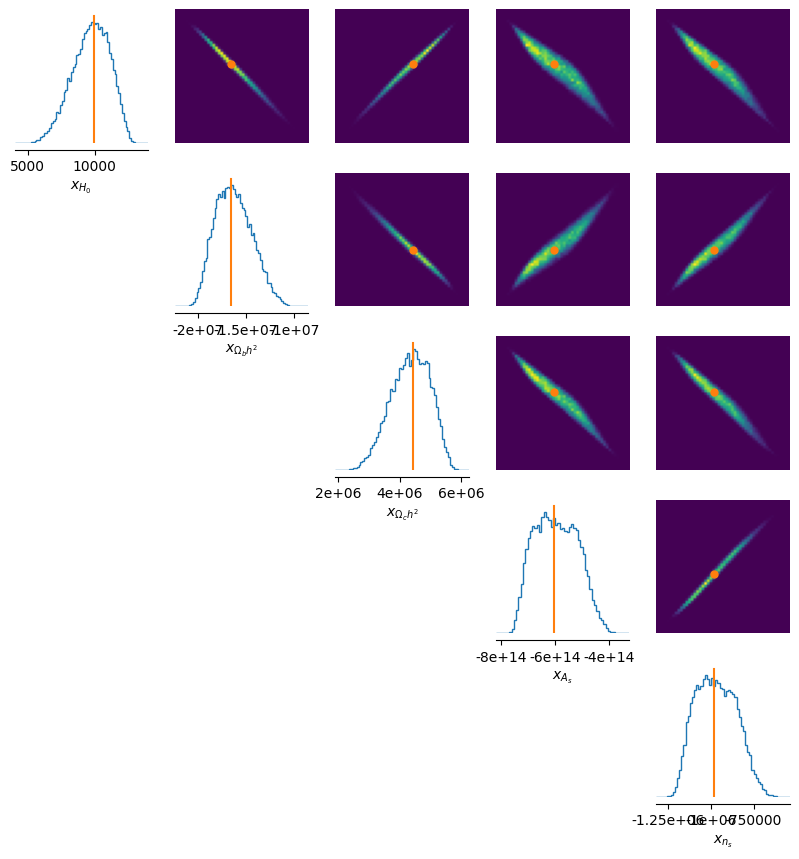

In [8]:
plot_checker(x_train_1, x_obs_1)

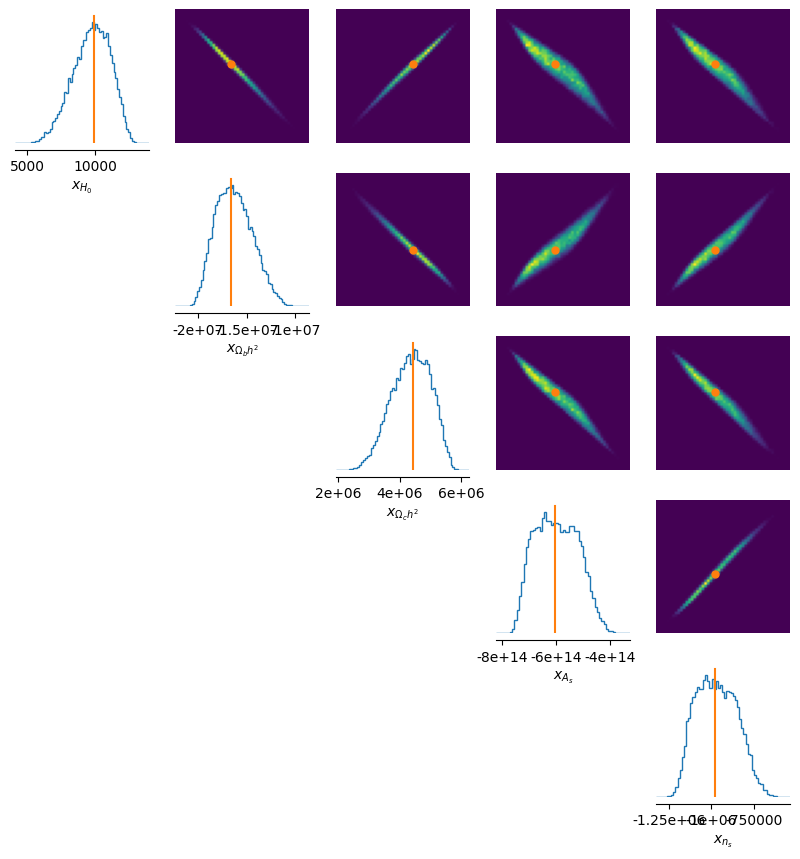

In [9]:
plot_checker(x_train_2, x_obs_2)

 Neural network successfully converged after 258 epochs.

/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-03T06_15_06.592218' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([ 9.9306e+03, -1.6533e+07,  4.4339e+06, -6.0252e+14, -9.7877e+05])


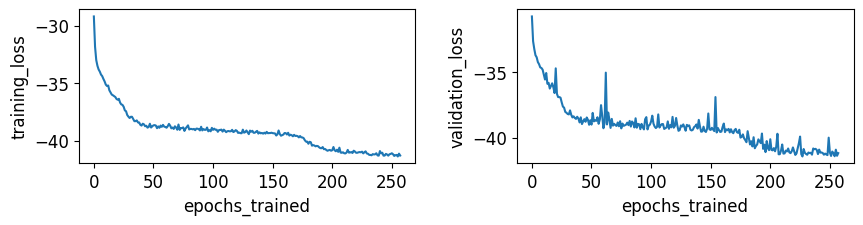

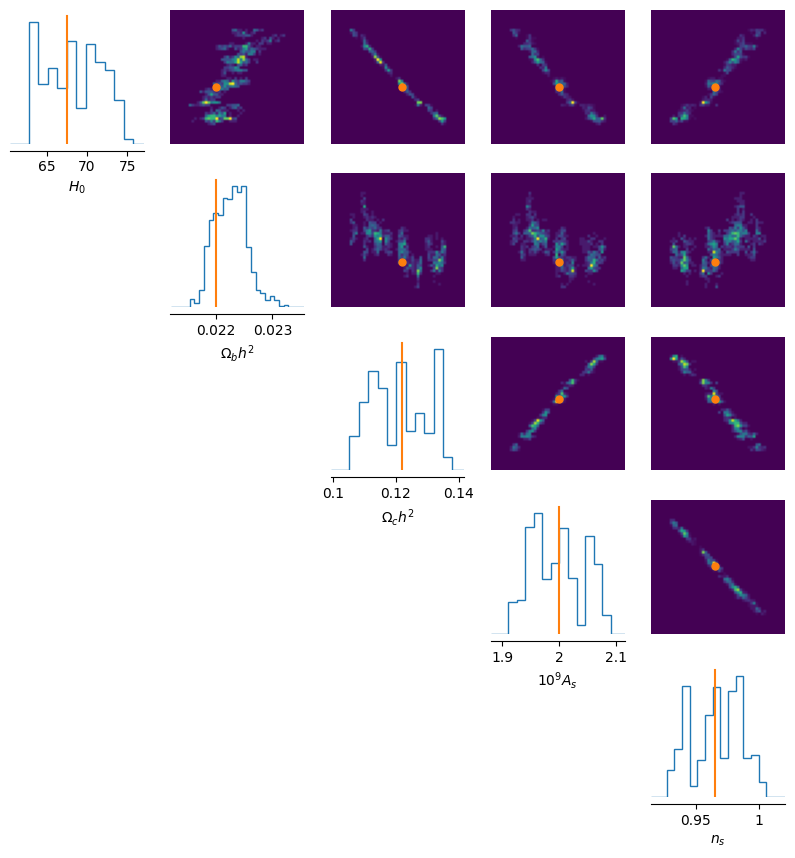

In [10]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(
    x_train_1, theta, x_obs_1, prior, verbose=True, max_epoch=10000, true_val=theta_true
)

 Neural network successfully converged after 239 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-03T06_42_53.793883' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([ 9.9537e+03, -1.6572e+07,  4.4428e+06, -6.0335e+14, -9.8047e+05])


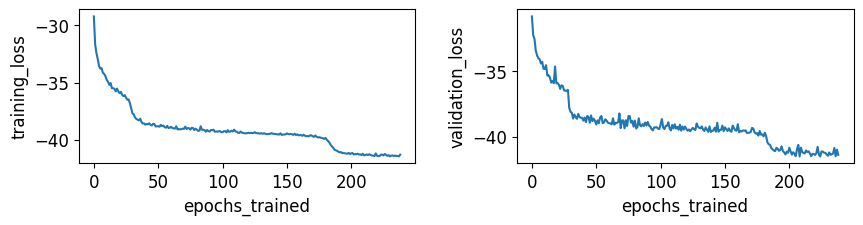

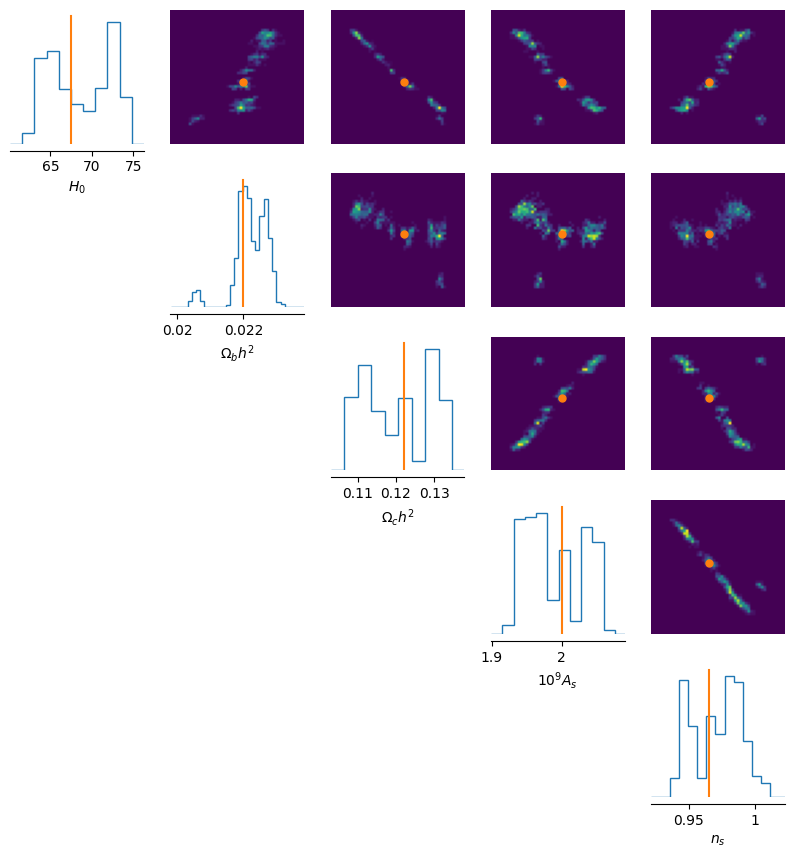

In [11]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(
    x_train_2, theta, x_obs_2, prior, verbose=True, max_epoch=10000, true_val=theta_true
)

##### In future add some posterior checks here

#### Saving Results

In [12]:
results = {
    "samples1":          samples1,          # posterior samples (N, 5) — null split
    "samples2":          samples2,          # posterior samples (N, 5) — systematic split
    "posterior1_mcmc":   posterior1_mcmc,
    "posterior1_direct": posterior1_direct,
    "posterior2_mcmc":   posterior2_mcmc,
    "posterior2_direct": posterior2_direct,
    "inference1":        inference1,        # NPE trained on even-ell, null beam
    "inference2":        inference2,        # NPE trained on odd-ell, beam systematic
    "prior":             prior,
    "theta":             theta,             # training theta (N, 5)
    "x_train_1":         x_train_1,         # training summaries, even-ell, null beam
    "x_train_2":         x_train_2,         # training summaries, odd-ell, beam systematic
    "x_obs_1":           x_obs_1,           # observed summary, even-ell, null beam
    "x_obs_2":           x_obs_2,           # observed summary, odd-ell, beam systematic
    "nl_base":           nl_base,           # noise spectrum (consistent throughout)
    "beam_base":         beam_base,         # null beam FWHM (arcmin)
    "beam_systematic":   beam_systematic,   # systematic beam FWHM (arcmin)
    "mask_even":         mask_even,         # float mask selecting even-ell multipoles
    "mask_odd":          mask_odd,          # float mask selecting odd-ell multipoles
    "TRUE_SEED_CMB":     TRUE_SEED_CMB,
    "TRUE_SEED_NOISE":   TRUE_SEED_NOISE,
    # Compressor saved as arrays — reconstruct with make_compressor() after loading
    "fiducial":          fiducial,          # fiducial C_ell spectrum (numpy)
    "cov":               cov,               # diagonal covariance (numpy)
    "derivs":            derivs,            # MOPED derivative vectors (numpy)
    "theta_true":        theta_true,        # fiducial cosmology (5,)
    "unique_seeds":      unique_seeds,
}

fname = "cmb_test_beam_odd_even_split_point1.pt"
torch.save(results, fname)


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/torch/serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


### KL Section

#### Load Results

In [13]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior",
        "theta",
        "x_train_1", "x_train_2",
        "x_obs_1", "x_obs_2",
        "nl_base",
        "beam_base", "beam_systematic", "mask_even", "mask_odd",
        "TRUE_SEED_CMB", "TRUE_SEED_NOISE",
        "fiducial", "cov", "derivs",
        "theta_true", "unique_seeds",
    ]

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [14]:
fname = "cmb_test_beam_odd_even_split_point1.pt"

res = load_results_file(fname)

(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior,
 theta,
 x_train_1, x_train_2,
 x_obs_1, x_obs_2,
 nl_base,
 beam_base, beam_systematic, mask_even, mask_odd,
 TRUE_SEED_CMB, TRUE_SEED_NOISE,
 fiducial, cov, derivs,
 theta_true, unique_seeds,
) = extract_results(res)

# Reconstruct the compressor closure from its saved arrays
my_compressor = make_compressor(fiducial, cov, derivs)


/tmp/ipykernel_493138/2643565374.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


#### Plot posteriors overlayed

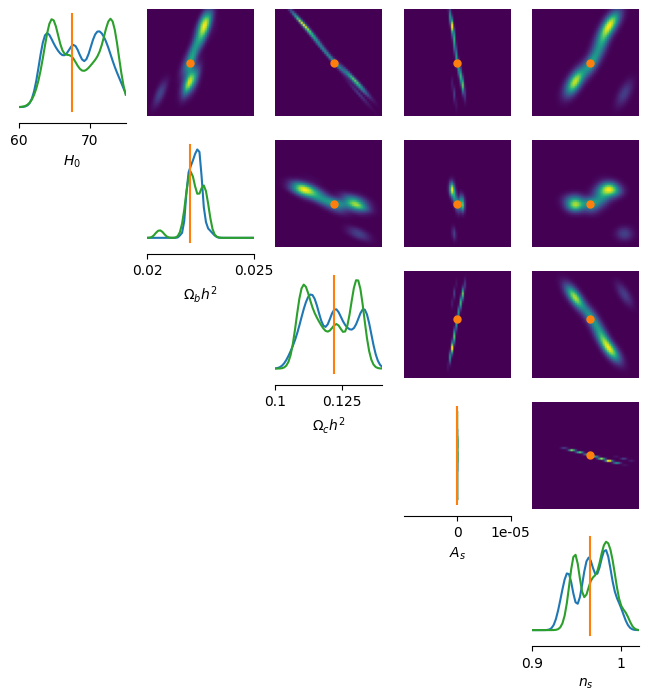

In [15]:
param_labels = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$A_s$",
    r"$n_s$",
]

# Use prior bounds as plot limits for a clean, comparable view of both posteriors
limits = [
    [60.0,   75.0  ],
    [0.020,  0.025 ],
    [0.10,   0.14  ],
    [1.5e-9, 2.5e-9],
    [0.90,   1.02  ],
]

_ = pairplot(
    samples=[samples1, samples2],
    points=theta_true,
    limits=limits,
    upper="kde",
    diag="kde",
    figsize=(8, 8),
    labels=param_labels,
)

#### Better pairplots (Will's Apr-9 / Apr-14 asks)

Three diagnostic views, in both `sbi.pairplot` and `getdist` flavours:
1. **Prior vs posteriors** — how much is learned
2. **Fisher vs NPE posteriors** — analytic validation
3. **Null vs systematic posteriors** — the test we actually care about


In [ ]:
# ============================================================
# Presentation-quality pairplots — sbi.pairplot version
# (Will's April-9 asks: prior shrinkage, Fisher validation,
#  null vs systematic overlay)
# ============================================================

import matplotlib as mpl
import matplotlib.patches as mpatches
from torch.distributions import MultivariateNormal

_RC = {
    "font.size":       16,
    "axes.labelsize":  18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titlesize":  16,
}

PARAM_LABELS = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$10^9 A_s$",
    r"$n_s$",
]


def _style_axes(axes):
    """Enforce presentation-quality font sizes on sbi.pairplot axes."""
    for row in axes:
        for ax in row:
            if ax is None:
                continue
            ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
            ax.xaxis.label.set_size(17)
            ax.yaxis.label.set_size(17)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)


def _add_legend(fig, entries):
    """Figure-level legend in the bottom-left corner."""
    handles = [mpatches.Patch(facecolor=c, edgecolor="0.3", linewidth=0.8, label=lbl)
               for c, lbl in entries]
    leg = fig.legend(
        handles=handles, fontsize=15, frameon=True,
        facecolor="white", edgecolor="0.3",
        loc="lower left", bbox_to_anchor=(0.02, 0.02),
        borderpad=0.9, handlelength=1.5, handleheight=1.2,
    )
    leg.get_frame().set_linewidth(1.0)


def _scale_As(s):
    """Return a float32 tensor with A_s (col 3) scaled by 1e9 for display."""
    if not torch.is_tensor(s):
        s = torch.tensor(np.asarray(s, dtype=np.float32))
    s = s.clone().float()
    s[:, 3] = s[:, 3] * 1e9
    return s


def _prior_limits_from_samples(prior_samples_display, pad_frac=0.02):
    """Empirical min/max of prior samples (display units) with a small pad.
    Works for any prior type (MultivariateNormal, BoxUniform, ...)."""
    arr = prior_samples_display.numpy() if torch.is_tensor(prior_samples_display) \
          else np.asarray(prior_samples_display, dtype=float)
    mn, mx = arr.min(axis=0), arr.max(axis=0)
    pad    = pad_frac * (mx - mn)
    return [[mn[i] - pad[i], mx[i] + pad[i]] for i in range(5)]


def _sys_label(beam_systematic):
    if beam_systematic is not None:
        return f"NPE posterior — beam systematic ({beam_systematic:.4f} arcmin)"
    return "NPE posterior — systematic split"


def compute_fisher_posterior(derivs, cov, prior):
    """MOPED Fisher matrix  F = derivs @ diag(1/cov) @ derivs.T   shape (5,5)
    Posterior covariance  C_post = (F + C_prior^{-1})^{-1}.
    Falls back to diag(prior.variance) when prior has no covariance_matrix
    (e.g. BoxUniform — moment-matched Gaussian)."""
    F = (derivs / cov) @ derivs.T
    try:
        prior_cov = np.asarray(prior.covariance_matrix, dtype=float)
    except AttributeError:
        prior_cov = np.diag(np.asarray(prior.variance, dtype=float))
    C_prior_inv = np.linalg.inv(prior_cov)
    C_post      = np.linalg.inv(F + C_prior_inv)
    return F, C_post


def plot_prior_vs_posteriors(samples1, samples2, prior, theta_true,
                              beam_systematic=None, n_prior_samples=100_000):
    """Shows how much the posteriors shrink relative to the prior."""
    prior_samples = prior.sample((n_prior_samples,))
    prior_plot    = _scale_As(prior_samples)
    post1_plot    = _scale_As(samples1)
    post2_plot    = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[prior_plot, post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=_prior_limits_from_samples(prior_plot),
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "Prior"),
        ("#2ca02c", "NPE posterior — null split"),
        ("#9467bd", _sys_label(beam_systematic)),
    ])
    fig.suptitle("Prior vs Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_fisher_vs_posteriors(samples1, samples2, prior, theta_true,
                               derivs, cov, beam_systematic=None,
                               n_fisher_samples=50_000):
    """Compares analytic Fisher prediction against both NPE posteriors."""
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_true_np  = np.asarray(theta_true, dtype=float)
    fisher_dist    = MultivariateNormal(
        loc=torch.tensor(theta_true_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))

    post1_plot  = _scale_As(samples1)
    post2_plot  = _scale_As(samples2)
    fisher_plot = _scale_As(fisher_samples)

    theta_true_plot    = theta_true_np.copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    # Tight limits: ±4.5σ around the combined cloud
    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy(),
                              fisher_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot, fisher_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(beam_systematic)),
        ("#9467bd", "Fisher prediction (analytic Gaussian)"),
    ])
    fig.suptitle("Fisher Prediction vs NPE Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nParameter 1σ widths  (A_s in units of 10^9 A_s):")
    print(f"{'Parameter':<20} {'Fisher σ':>12} {'NPE σ (null)':>14} {'NPE σ (sys)':>13}")
    print("─" * 63)
    fisher_stds = np.sqrt(np.diag(C_post))
    npe1_stds   = post1_plot.numpy().std(axis=0)
    npe2_stds   = post2_plot.numpy().std(axis=0)
    for i, lbl in enumerate(PARAM_LABELS):
        f_s = fisher_stds[i] * (1e9 if i == 3 else 1.0)
        print(f"{lbl:<20} {f_s:>12.4g} {npe1_stds[i]:>14.4g} {npe2_stds[i]:>13.4g}")

    return F, C_post


def plot_posteriors_overlaid(samples1, samples2, prior, theta_true,
                              beam_systematic=None):
    """Just the two posteriors, tight limits."""
    post1_plot = _scale_As(samples1)
    post2_plot = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(beam_systematic)),
    ])
    fig.suptitle("Null vs Systematic Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_prior_vs_posteriors(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)

F, C_post = plot_fisher_vs_posteriors(
    samples1, samples2, prior, theta_true, derivs, cov,
    beam_systematic=beam_systematic,
)

plot_posteriors_overlaid(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)


In [ ]:
# ============================================================
# getdist versions of the three diagnostic plots
# (Will's Apr-14 suggestion to use getdist/corner over sbi.pairplot)
# ============================================================

# Install getdist on first run (comment out after)
#%pip install --quiet getdist

from getdist import MCSamples, plots as gd_plots

GD_NAMES  = ["H0", "ombh2", "omch2", "As_scaled", "ns"]
GD_LABELS = ["H_0", r"\Omega_b h^2", r"\Omega_c h^2", r"10^9 A_s", "n_s"]


def _to_mcsamples(samples, label):
    """Convert (N,5) tensor/array to MCSamples with A_s scaled by 1e9."""
    arr = samples.numpy() if torch.is_tensor(samples) else np.asarray(samples)
    arr = arr.astype(float).copy()
    arr[:, 3] *= 1e9
    return MCSamples(samples=arr, names=GD_NAMES, labels=GD_LABELS, label=label)


def _make_plotter(width_inch=13):
    g = gd_plots.get_subplot_plotter(width_inch=width_inch)
    # Peak=1 normalisation for 1D marginals (Will's request — shape comparison
    # without sample-count bias)
    g.settings.norm_1d_density          = True
    g.settings.alpha_filled_add         = 0.6
    g.settings.axes_fontsize            = 13
    g.settings.lab_fontsize             = 18
    g.settings.legend_fontsize          = 14
    g.settings.linewidth                = 2.0
    g.settings.linewidth_contour        = 2.0
    g.settings.solid_contour_palefactor = 0.7
    return g


def _theta_true_markers(theta_true):
    t = np.asarray(theta_true, dtype=float).copy()
    t[3] *= 1e9
    return dict(zip(GD_NAMES, t))


def _sys_label_gd(beam_systematic):
    if beam_systematic is not None:
        return f"NPE posterior - beam systematic ({beam_systematic:.4f} arcmin)"
    return "NPE posterior - systematic split"


def plot_prior_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                 beam_systematic=None, n_prior_samples=100_000):
    mc_prior = _to_mcsamples(prior.sample((n_prior_samples,)), "Prior")
    mc_null  = _to_mcsamples(samples1, "NPE posterior - null split")
    mc_sys   = _to_mcsamples(samples2, _sys_label_gd(beam_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_prior, mc_null, mc_sys],
        filled=True,
        contour_colors=["#888888", "#1f77b4", "#ff7f0e"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Prior vs Posteriors (getdist)", fontsize=22, fontweight="bold", y=1.02)
    plt.show()


def plot_fisher_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                  derivs, cov, beam_systematic=None,
                                  n_fisher_samples=50_000):
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_np  = np.asarray(theta_true, dtype=float)
    fisher_dist = MultivariateNormal(
        loc=torch.tensor(theta_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))

    mc_null   = _to_mcsamples(samples1,       "NPE posterior - null split")
    mc_sys    = _to_mcsamples(samples2,       _sys_label_gd(beam_systematic))
    mc_fisher = _to_mcsamples(fisher_samples, "Fisher prediction (analytic Gaussian)")

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys, mc_fisher],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Fisher Prediction vs NPE Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()
    return F, C_post


def plot_posteriors_overlaid_gd(samples1, samples2, prior, theta_true,
                                 beam_systematic=None):
    mc_null = _to_mcsamples(samples1, "NPE posterior - null split")
    mc_sys  = _to_mcsamples(samples2, _sys_label_gd(beam_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Null vs Systematic Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_gd(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)
_ = plot_fisher_vs_posteriors_gd(
    samples1, samples2, prior, theta_true, derivs, cov,
    beam_systematic=beam_systematic,
)
plot_posteriors_overlaid_gd(
    samples1, samples2, prior, theta_true,
    beam_systematic=beam_systematic,
)


#### Define and calculate KL

In [ ]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error


def calibrate_null_dkl(posterior1, posterior2, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs, mask_even, mask_odd):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky AND same noise draw for both splits (seed_cmb=i, seed_noise=i+1M).
        # The only difference is the ell mask (even vs odd multipoles).
        # No beam systematic in the null — both use beam_null.
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_odd)

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=1, label='Observed D_KL Value')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=1, label='95% Critical Value')
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.legend()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


In [ ]:
dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct,
                                       x_obs_1, x_obs_2, n_theta=500)
print("DKL observed:", dkl_obs)

# Redundant: superseded by calibrate_null_dkl_neat below.
# dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, posterior2_direct, prior,
#                                        100, 500, my_compressor, nl_base, beam_base,
#                                        dkl_obs, mask_even, mask_odd)


In [ ]:
def calibrate_null_dkl_neat(posterior1, posterior2, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs, mask_even, mask_odd):
    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 250 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky AND same noise draw for both splits (seed_cmb=i, seed_noise=i+1M).
        # The only difference is the ell mask (even vs odd multipoles).
        # No beam systematic in the null — both use beam_null.
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_odd)

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PLOTTING
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid *behind* the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label=r'Null Distribution ($H_0$)')
    
    # Vertical lines
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    plt.tight_layout()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


In [ ]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(
    posterior1_direct, posterior2_direct, prior,
    500, 500, my_compressor, nl_base, beam_base,
    dkl_obs, mask_even, mask_odd,
)
print("DKL observed:", dkl_obs)


#### Perturbation Calc

In [ ]:
def calibrate_null_dkl_and_perturbed(posterior1, posterior2, prior, N, n_theta,
                                     compressor, nl_null, beam_null, beam_perturbed,
                                     mask_even, mask_odd):

    dkls = np.zeros(N)
    dkls_perturbed = np.zeros(N)
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same sky and noise for both splits — only ell mask differs.
        # Null: even-ell (null beam) vs odd-ell (null beam).
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_odd)
        # Perturbed: ODD-ell split gets the systematic beam (mirrors x_obs_2).
        # Even-ell split stays null.
        x2_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_perturbed,
                                           seed_cmb=i, seed_noise=i + 1_000_000,
                                           ell_mask=mask_odd)

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2,
                                           x1_i, x2_i, n_theta=n_theta)
        dkls_perturbed[i], std_dev2, error2 = calc_dkl(posterior1, posterior2,
                                                       x1_i, x2_i_perturbed,
                                                       n_theta=n_theta)

    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))

    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title(r"Perturbed calibration of $D_{KL}$ (systematic injected into odd-ell split)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed


In [ ]:
# Redundant: the refactored sweep below covers null + perturbed at multiple
# multipliers. Skipping this one-shot call saves ~100 calc_dkl iterations.
# dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed = calibrate_null_dkl_and_perturbed(
#     posterior1_direct, posterior2_direct, prior,
#     100, 500, my_compressor, nl_base, beam_base, beam_systematic,
#     mask_even, mask_odd,
# )


#### this needs adapting a little but is the looping through shifts to find sensitivity (get rid of all analytical stuff as not gaussian anymore)

In [ ]:
def calibrate_null_dkl_and_perturb_mean(posterior1, posterior2, prior, N, n_theta,
                                        compressor, nl_null, beam_null, multiplier,
                                        mask_even, mask_odd):

    # Build perturbed beam from multiplier
    beam_perturbed = beam_null * multiplier

    dkls = np.zeros(N)
    dkls_perturbed = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same sky and noise for both splits — only ell mask differs.
        # Null: even-ell (null beam) vs odd-ell (null beam).
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_odd)
        # Perturbed: ODD-ell split gets the systematic beam (mirrors x_obs_2).
        x2_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_perturbed,
                                           seed_cmb=i, seed_noise=i + 1_000_000,
                                           ell_mask=mask_odd)

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2,
                                           x1_i, x2_i, n_theta=n_theta)
        dkls_perturbed[i], std_dev2, error2 = calc_dkl(posterior1, posterior2,
                                                       x1_i, x2_i_perturbed,
                                                       n_theta=n_theta)

    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    median_perturbed = float(np.median(dkls_perturbed))

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed, median_perturbed


In [ ]:
# ============================================================
# Refactored split: null calibration once, perturbed sweep separately
# ============================================================
# `calibrate_null_dkl_and_perturb_mean` does both in one loop, which is
# wasteful when sweeping multipliers (the null distribution is multiplier-
# independent). Run the null at high N once, then sweep perturbed-only.

def calibrate_null_dkl_only(posterior1, posterior2, prior, N, n_theta,
                             compressor, nl_null, beam_null,
                             mask_even, mask_odd):
    """Null distribution of D_KL: same sky, same noise, null beam, even vs odd
    multipole splits. Run once at high N (e.g. 1000-2000) - sets test threshold."""
    dkls = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"null {i}/{N}")
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_odd)
        dkls[i], _, _ = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta)
    crit_val_95 = float(np.quantile(dkls, 0.95))
    return dkls, crit_val_95


def calibrate_perturb_dkl_only(posterior1, posterior2, prior, N, n_theta,
                                compressor, nl_null, beam_null,
                                mask_even, mask_odd, multiplier):
    """Perturbed distribution: even-ell split uses null beam, odd-ell split
    uses beam_null * multiplier. Lower N is fine - only the median matters."""
    beam_perturbed = beam_null * multiplier
    dkls_p = np.zeros(N)
    for i in range(N):
        if i % 100 == 0:
            print(f"  perturb (m={multiplier}) {i}/{N}")
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 ell_mask=mask_even)
        x2_i_pert = blanket_simulator(theta_i, compressor, nl_null,
                                       beam_fwhm=beam_perturbed,
                                       seed_cmb=i, seed_noise=i + 1_000_000,
                                       ell_mask=mask_odd)
        dkls_p[i], _, _ = calc_dkl(posterior1, posterior2, x1_i, x2_i_pert,
                                    n_theta=n_theta)
    median_perturbed = float(np.median(dkls_p))
    return dkls_p, median_perturbed


In [ ]:
# Refactored sweep: null calibration ONCE at high N, then perturbed-only sweep
# at lower N. This cuts compute roughly in half compared to recomputing the
# null at every multiplier.

N_null         = 1000   # high N for a clean 95th percentile threshold
N_pert         = 300    # lower N for each perturbed multiplier
n_theta_sweep  = 500

multipliers_to_test = [1.001, 1.0015, 1.002, 1.003, 1.004, 1.005, 1.0075, 1.01]  # sweep beam_base * x

print("--- Null calibration (run once) ---")
dkls, crit_val_95 = calibrate_null_dkl_only(
    posterior1_direct, posterior2_direct, prior,
    N_null, n_theta_sweep, my_compressor, nl_base, beam_base,
    mask_even=mask_even, mask_odd=mask_odd,
)
print(f"Null 95% critical value: {crit_val_95:.3f}")

sweep_results = []
sensitivity_threshold_reached = False
last_multiplier = None
last_dkls_perturbed = None

for multiplier_val in multipliers_to_test:
    print(f"\n--- Perturbed sweep multiplier = {multiplier_val} ---")
    dkls_perturbed, median_perturbed = calibrate_perturb_dkl_only(
        posterior1_direct, posterior2_direct, prior,
        N_pert, n_theta_sweep, my_compressor, nl_base, beam_base,
        mask_even=mask_even, mask_odd=mask_odd, multiplier=multiplier_val,
    )
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    detected = median_perturbed >= crit_val_95
    sweep_results.append((multiplier_val, median_perturbed, crit_val_95_perturbed, detected))
    last_multiplier = multiplier_val
    last_dkls_perturbed = dkls_perturbed
    print(f"m={multiplier_val:.5f}  median DKL={median_perturbed:.3f}  "
          f"null 95%={crit_val_95:.3f}  detected={detected}")
    if detected and not sensitivity_threshold_reached:
        print(f">>> 2-Sigma Sensitivity Reached at multiplier = {multiplier_val}! <<<")
        sensitivity_threshold_reached = True
        break

dkls_perturbed = last_dkls_perturbed
median_perturbed = float(np.median(dkls_perturbed))
crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))

# ==========================================
# NULL CALIBRATION PLOT
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls, bins=30, density=True, alpha=0.8, color='tab:blue', label='NPE Posteriors (Null)')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=1,
            label=f'95% Critical Value ({crit_val_95:.2f})')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(rf"Null calibration of $D_{{KL}}$ (N={N_null})")
plt.show()

# ==========================================
# PERTURBED CALIBRATION PLOT (last multiplier tested)
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Odd-ell perturbed: {last_multiplier}x beam)')
plt.axvline(crit_val_95, color='black', linestyle='dashed', linewidth=1, label='95% Null Threshold')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(rf"Perturbed calibration of $D_{{KL}}$ (N={N_pert})")
plt.show()

print(f"Null 95 percent critical value:      {crit_val_95:.3f}")
print(f"Perturbed 95 percent critical value: {crit_val_95_perturbed:.3f}")
print(f"Perturbed median:                    {median_perturbed:.3f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. NULL CALIBRATION GRAPH
# ==========================================
# Plot
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls, bins=30, density=True, color='tab:blue', label='NPE Posteriors (Null)')

plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()


# ==========================================
# 2. PERTURBED CALIBRATION GRAPH
# ==========================================
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Odd-ell perturbed: {multiplier_val:.3f}x beam)')

# Vertical threshold line (thicker, with dynamic value injected into legend)
plt.axvline(median_perturbed, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Median Perturbed ({median_perturbed:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Null Threshold ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(rf"Perturbed Calibration of $D_{{KL}}$ (Odd/Even Split, {multiplier_val:.3f}x Beam)",
          fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# Print statements formatted to 2 decimal places for neatness
print(f"Null 95 percent critical value:      {crit_val_95:.2f}")
print(f"Perturbed 95 percent critical value: {crit_val_95_perturbed:.2f}")
